https://github.com/NASA-IMPACT/hls-foundation-os/blob/main/exploration.ipynb

In [ ]:
!apt-get update && apt-get install git-lfs -y
!git lfs install
!cd "data/" && git clone "https://huggingface.co/ibm-nasa-geospatial/Prithvi-100M" && cd -

In [2]:
!uv pip install -r "data/Prithvi-100M/requirements.txt"

Audited 5 packages in 30ms


In [12]:
import sys
sys.path.append("data/Prithvi-100M/")

In [24]:
import os
from os.path import join
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import yaml
from prithvi_mae import PrithviMAE

NO_DATA = -9999
NO_DATA_FLOAT = 0.0001
PERCENTILES = (0.1, 99.9)

In [25]:
root = Path("data/Prithvi-100M/")

In [20]:
def load_raster(path, crop=None):
    with rasterio.open(path) as src:
        img = src.read()

        # load first 6 bands
        img = img[:6]

        img = np.where(img == NO_DATA, NO_DATA_FLOAT, img)
        if crop:
            img = img[:, -crop[0]:, -crop[1]:]
    return img

def enhance_raster_for_visualization(raster, ref_img=None):
    if ref_img is None:
        ref_img = raster
    channels = []
    for channel in range(raster.shape[0]):
        valid_mask = np.ones_like(ref_img[channel], dtype=bool)
        valid_mask[ref_img[channel] == NO_DATA_FLOAT] = False
        mins, maxs = np.percentile(ref_img[channel][valid_mask], PERCENTILES)
        normalized_raster = (raster[channel] - mins) / (maxs - mins)
        normalized_raster[~valid_mask] = 0
        clipped = np.clip(normalized_raster, 0, 1)
        channels.append(clipped)
    clipped = np.stack(channels)
    channels_last = np.moveaxis(clipped, 0, -1)[..., :3]
    rgb = channels_last[..., ::-1]
    return rgb

In [21]:
def plot_image_mask_reconstruction(normalized, mask_img, pred_img):
    # Mix visible and predicted patches
    rec_img = normalized.clone()
    rec_img[mask_img == 1] = pred_img[mask_img == 1]  # binary mask: 0 is keep, 1 is remove

    mask_img_np = mask_img.numpy().reshape(6, 224, 224).transpose((1, 2, 0))[..., :3]

    rec_img_np = (rec_img.numpy().reshape(6, 224, 224) * stds) + means
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 6))

    for subplot in ax:
        subplot.axis('off')

    ax[0].imshow(enhance_raster_for_visualization(input_data))
    masked_img_np = enhance_raster_for_visualization(input_data).copy()
    masked_img_np[mask_img_np[..., 0] == 1] = 0
    ax[1].imshow(masked_img_np)
    ax[2].imshow(enhance_raster_for_visualization(rec_img_np, ref_img=input_data))

In [32]:

# load weights
weights_path = root / "Prithvi_100M.pt"
checkpoint = torch.load(weights_path, map_location="cpu")

# read model config
model_cfg_path = root / "config.yaml"
with open(model_cfg_path) as f:
    model_config = yaml.safe_load(f)

model_args, train_args = model_config["model_args"], model_config["train_params"]

# let us use only 1 frame for now (the model was trained on 3 frames)
model_args["num_frames"] = 1

# instantiate model
model = PrithviMAE(**model_args)
model.eval()

# load weights into model
# strict=false since we are loading with only 1 frame, but the warning is expected
del checkpoint['encoder.pos_embed']
del checkpoint['decoder.decoder_pos_embed']

_ = model.load_state_dict(checkpoint, strict=False)

/tmp/ipykernel_86/1415790755.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location="cpu")


Input data shape is (6, 224, 224)


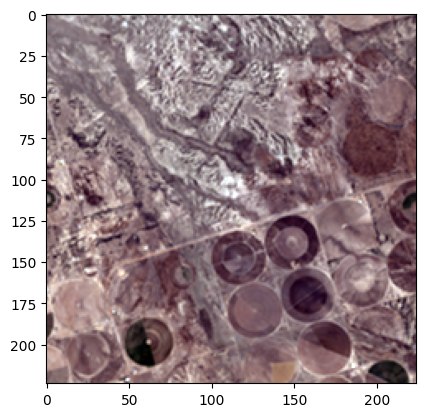

In [34]:
raster_path = root / "examples/HLS.L30.T13REN.2018013T172747.v2.0.B02.B03.B04.B05.B06.B07_cropped.tif"
input_data = load_raster(raster_path, crop=(224, 224))
print(f"Input data shape is {input_data.shape}")
raster_for_visualization = enhance_raster_for_visualization(input_data)
plt.imshow(raster_for_visualization)

In [50]:
# statistics used to normalize images before passing to the model
means = np.array(train_args["data_mean"]).reshape(-1, 1, 1)
stds = np.array(train_args["data_std"]).reshape(-1, 1, 1)

def preprocess_image(image):
    # normalize image
    C, H, W = image.shape
    normalized = image.copy()
    normalized = ((image - means) / stds)
    normalized = normalized.reshape(1, C, 1, H, W)
    normalized = torch.from_numpy(normalized).to(torch.float32)
    return normalized

In [51]:
normalized = preprocess_image(input_data)
with torch.inference_mode():
    mask_ratio = 0.5
    _, pred, mask = model(normalized, mask_ratio=mask_ratio)
    mask_img = model.unpatchify(mask.unsqueeze(-1).repeat(1, 1, pred.shape[-1])).detach().cpu()
    pred_img = model.unpatchify(pred).detach().cpu()

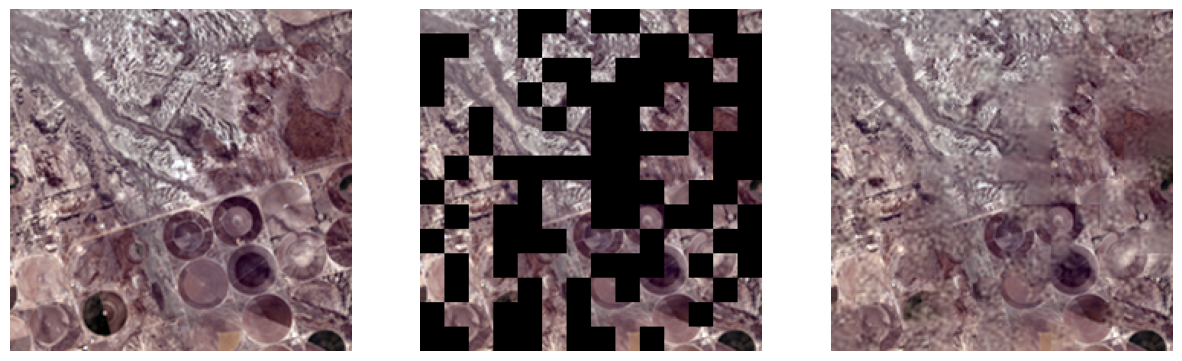

In [52]:
plot_image_mask_reconstruction(normalized, mask_img, pred_img)

In [55]:
# if going with plain pytorch:
# - remember to normalize images beforehand (find the normalization statistics in the config file)
# - turn off masking by passing mask_ratio = 0
normalized = preprocess_image(input_data)
features = model.forward_features(normalized)

In [54]:
input_data.shape, normalized.shape

((6, 224, 224), torch.Size([1, 6, 1, 224, 224]))

In [56]:
len(features), [f.shape for f in features]

(12,
 [torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768]),
  torch.Size([1, 197, 768])])

In [64]:
model.encoder.patch_embed.num_frames

AttributeError: 'PatchEmbed' object has no attribute 'num_frames'

In [ ]:
print(f"Encoder features have shape {features.shape}")

# drop cls token
reshaped_features = features[:, 1:, :]

# reshape
feature_img_side_length = int(np.sqrt(reshaped_features.shape[1]))
reshaped_features = reshaped_features.view(-1, feature_img_side_length, feature_img_side_length, model_args["embed_dim"])
# channels first
reshaped_features = reshaped_features.permute(0, 3, 1, 2)
print(f"Encoder features have new shape {reshaped_features.shape}")